**STEP 1**
Import Libraries and Load Data


In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading the data
data = pd.read_csv("e-shop clothing 2008.csv", sep = ";")

**STEP 2**
Understand the dataset


In [3]:
# Data Types
data.info()
data.dtypes
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

,year,month,day,order,country,session ID,page 1 (main category),colour,location,model photography,price,price 2,page
count,165474.0,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000
mean,2008.0,5.585887,14.524554,9.817476,26.952621,12058.417056,2.400842,6.227655,3.258198,1.260071,43.802507,1.488167,1.710166
std,0.0,1.328160,8.830374,13.478411,7.150691,7008.418903,1.144420,4.235606,1.713206,0.438674,12.548131,0.499861,0.982412
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5931.000000,1.000000,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11967.500000,2.000000,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18219.000000,3.000000,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,47.000000,24026.000000,4.000000,14.000000,6.000000,2.000000,82.000000,2.000000,5.000000


**STEP 3**
Execute data cleaning/cleansing

In [4]:
# Checking Null Values - Result = There is none
print(data.isnull().sum())

# If there is null values fill them with suitable values
for col in data.columns:
    if data[col].dtype == "object":
        data[col] = data[col].fillna("Unknown")
    else:
        data[col] = data[col].fillna(data[col].median())

# Removing duplicates (if there is)
data = data.drop_duplicates()

# Standardization for the column names
data.columns = data.columns.str.lower().str.replace(" ", "_")

# Checking the data again
data.info()
print(data.head())

year                       0
month                      0
day                        0
order                      0
country                    0
session ID                 0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session_id               165474 non-null  int64 
 6   page_1_(main_category)   165474 n

**STEP 4**
Create the DataFrame with the columns selected

In [5]:
"""
There are different types of KPI types but I will use :

Customer KPI
Operational KPI
Product KPI

"""
#print(data.head())

# Selecting necessary columns for KPI analysis
df = data[[
    "year",
    "month",
    "day",
    "country",
    "page_1_(main_category)",
    "page_2_(clothing_model)",
    "colour",
    "price",
    "price_2",
    "page",
    "session_id"
]].copy()  # Here I included a copy() function because I don't want to write on the main data

# Creating a count value for each session id (instead of geting session_id as column)
df["session_count"] = df.groupby("session_id")["session_id"].transform("count")


# Creating a date value
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# Sorting the datas according to the dates
df = df.sort_values("date")




#print(df.head())

Y = df["session_count"]
#print(Y)

# It's for the graphs
df_time = df.groupby("date")["session_count"].mean()
print(df_time.head(10))

date
2008-04-01    14.845332
2008-04-02    17.008681
2008-04-03    16.741100
2008-04-04    17.912826
2008-04-05    16.791223
2008-04-06    18.322531
2008-04-07    18.225986
2008-04-08    25.065230
2008-04-09    13.185010
2008-04-10    19.200647
Name: session_count, dtype: float64


**STEP 5**
Plot the data to understand the dependent and independent variables.

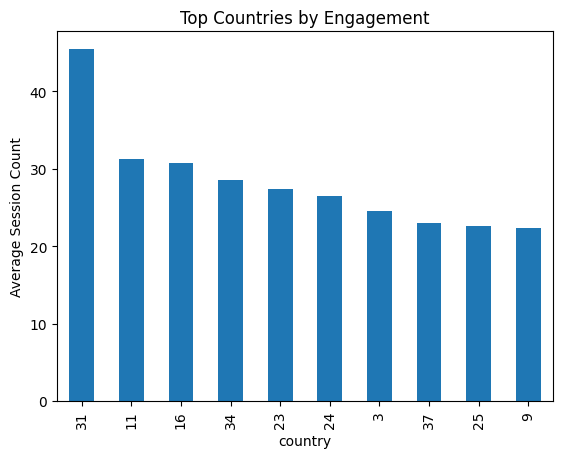

In [6]:
# Country Based Engagement

df.groupby("country")["session_count"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Countries by Engagement")
plt.ylabel("Average Session Count")
plt.show()

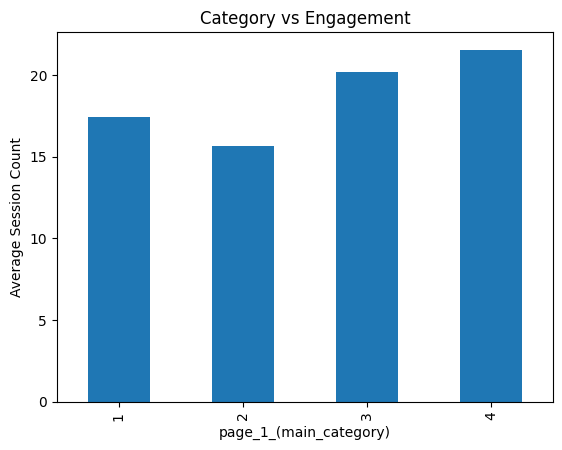

In [7]:
# Catgeory based engagement

df.groupby("page_1_(main_category)")["session_count"].mean().plot(kind="bar")
plt.title("Category vs Engagement")
plt.ylabel("Average Session Count")
plt.show()

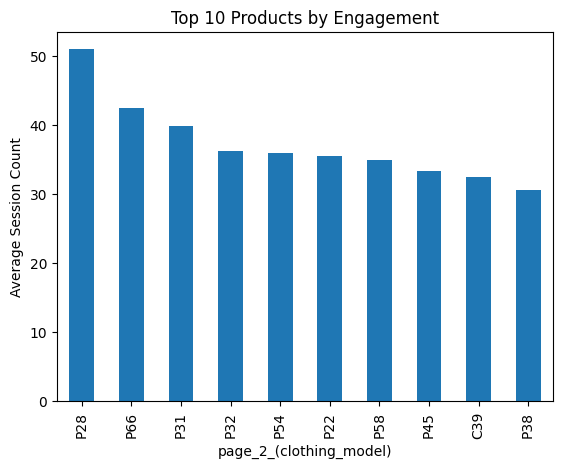

In [8]:
# Product Popularity

df.groupby("page_2_(clothing_model)")["session_count"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Products by Engagement")
plt.ylabel("Average Session Count")
plt.show()

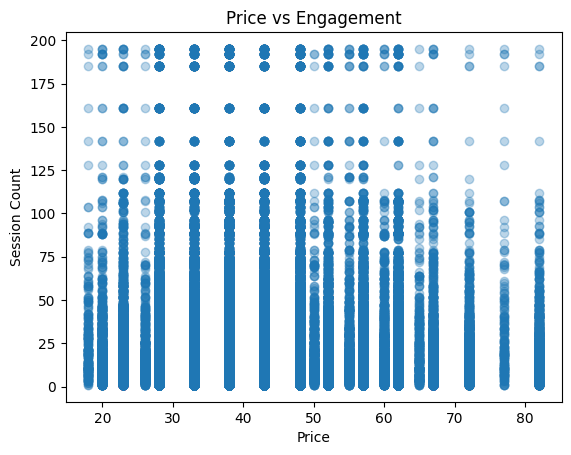

In [9]:
# Price based engagement

plt.scatter(df["price"], df["session_count"], alpha=0.3)
plt.title("Price vs Engagement")
plt.xlabel("Price")
plt.ylabel("Session Count")
plt.show()

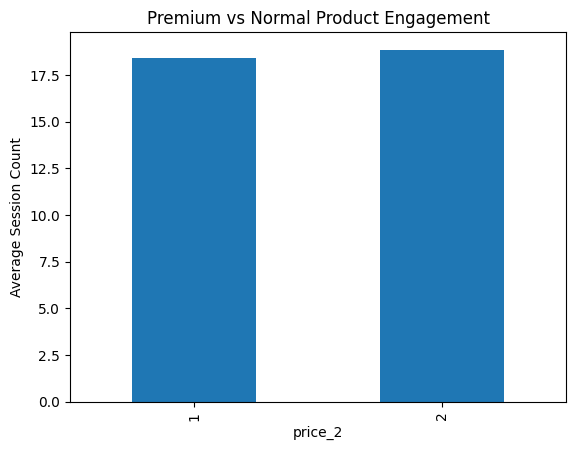

In [10]:
# Premium vs normal product engagement

df.groupby("price_2")["session_count"].mean().plot(kind="bar")
plt.title("Premium vs Normal Product Engagement")
plt.ylabel("Average Session Count")
plt.show()

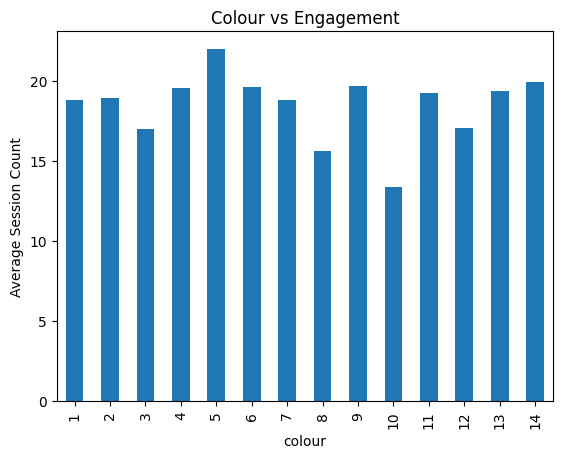

In [11]:
# Colour based engagement

df.groupby("colour")["session_count"].mean().plot(kind="bar")
plt.title("Colour vs Engagement")
plt.ylabel("Average Session Count")
plt.show()

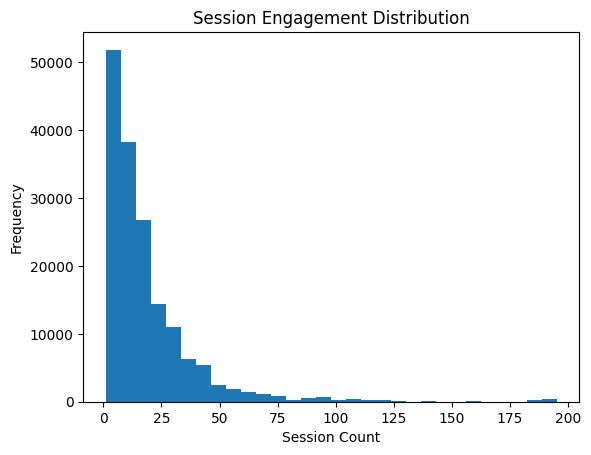

In [12]:
# Core engagement (Are users active or passive?)

plt.hist(df["session_count"], bins=30)
plt.title("Session Engagement Distribution")
plt.xlabel("Session Count")
plt.ylabel("Frequency")
plt.show()

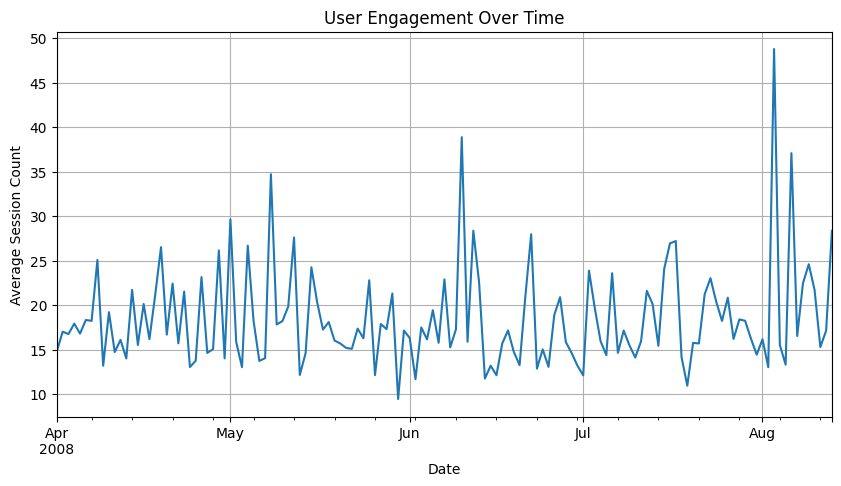

In [13]:
# Time based user engagement

df_time = df.groupby("date")["session_count"].mean()

plt.figure(figsize=(10,5))
df_time.plot()
plt.title("User Engagement Over Time")
plt.xlabel("Date")
plt.ylabel("Average Session Count")
plt.grid()
plt.show()

<Figure size 1000x500 with 0 Axes>

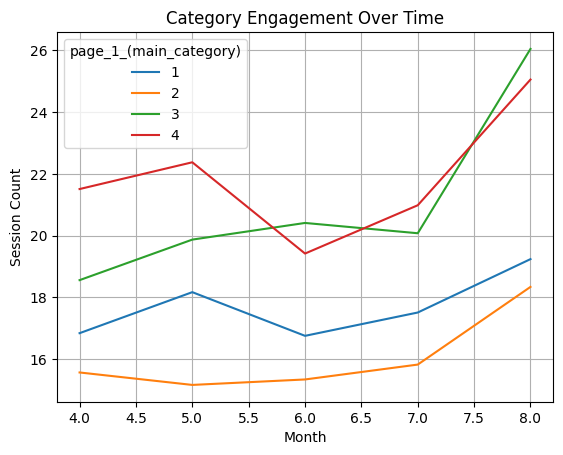

In [15]:
# Time based category engagement

df_cat_time = df.groupby(["month", "page_1_(main_category)"])["session_count"].mean().unstack()
plt.figure(figsize=(10,5))
df_cat_time.plot()
plt.title("Category Engagement Over Time")
plt.xlabel("Month")
plt.ylabel("Session Count")
plt.grid()
plt.show()